# Khảo sát dữ liệu thô để tìm Chunk Size phù hợp
Notebook này quét qua toàn bộ các file Markdown thu thập được, phân tách chúng thành các đoạn văn (Paragraphs) và tính toán độ dài tự nhiên của chúng. Mục đích là để tìm ra con số `max_child_size` tối ưu nhất dựa trên toán học và thống kê, thay vì đoán mò.

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# 1. Đọc toàn bộ dữ liệu thô (Raw Crawled Markdown)
md_files = glob.glob('../data/crawled_markdown/*.md')
print(f"Tìm thấy {len(md_files)} files markdown.")

all_paragraphs = []
for file in md_files:
    with open(file, 'r', encoding='utf-8') as f:
        content = f.read()
        # Loại bỏ phần YAML Frontmatter
        import re
        content = re.sub(r'^---\n.*?\n---\n+', '', content, flags=re.DOTALL)
        
        # Tách thành các khối văn bản tự nhiên (cách nhau bởi 1 dòng trắng)
        paragraphs = content.split('\n\n')
        for p in paragraphs:
            p = p.strip()
            if p:
                all_paragraphs.append(p)

Tìm thấy 161 files markdown.


In [3]:
# 2. Tính toán độ dài của từng đoạn văn
df = pd.DataFrame({'paragraph': all_paragraphs})
df['char_length'] = df['paragraph'].apply(len)
df['word_count'] = df['paragraph'].apply(lambda x: len(x.split()))

print("===== THỐNG KÊ ĐỘ DÀI ĐOẠN VĂN TỰ NHIÊN =====")
print(f"Tổng số đoạn văn: {len(df):,}")
print(f"Độ dài trung bình: {df['char_length'].mean():.0f} ký tự")
print(f"Đoạn văn dài nhất: {df['char_length'].max():,} ký tự")
print("\n--- Tỷ lệ bao phủ (Percentiles) ---")
for p in [50, 75, 90, 95, 99]:
    val = np.percentile(df['char_length'], p)
    print(f"{p}% đoạn văn có độ dài DƯỚI: {val:.0f} ký tự")

===== THỐNG KÊ ĐỘ DÀI ĐOẠN VĂN TỰ NHIÊN =====
Tổng số đoạn văn: 5,879
Độ dài trung bình: 189 ký tự
Đoạn văn dài nhất: 7,690 ký tự

--- Tỷ lệ bao phủ (Percentiles) ---
50% đoạn văn có độ dài DƯỚI: 90 ký tự
75% đoạn văn có độ dài DƯỚI: 222 ký tự
90% đoạn văn có độ dài DƯỚI: 392 ký tự
95% đoạn văn có độ dài DƯỚI: 603 ký tự
99% đoạn văn có độ dài DƯỚI: 1527 ký tự


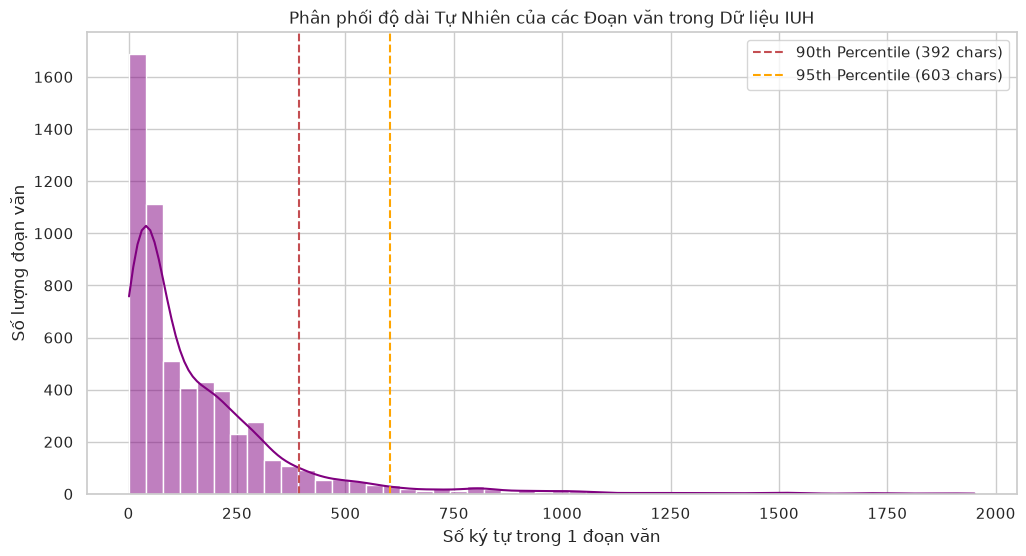

In [4]:
# 3. Vẽ biểu đồ phân phối
# Loại bỏ các đoạn văn quá dài (Outliers > 2000) để biểu đồ dễ nhìn hơn
filtered_df = df[df['char_length'] <= 2000]

plt.figure(figsize=(12, 6))
sns.histplot(filtered_df['char_length'], bins=50, kde=True, color='purple')

# Vẽ các đường Percentile
p90 = np.percentile(df['char_length'], 90)
p95 = np.percentile(df['char_length'], 95)
plt.axvline(p90, color='r', linestyle='--', label=f'90th Percentile ({p90:.0f} chars)')
plt.axvline(p95, color='orange', linestyle='--', label=f'95th Percentile ({p95:.0f} chars)')

plt.title('Phân phối độ dài Tự Nhiên của các Đoạn văn trong Dữ liệu IUH')
plt.xlabel('Số ký tự trong 1 đoạn văn')
plt.ylabel('Số lượng đoạn văn')
plt.legend()
plt.show()